# 06 — RSN Interpretability: Comparing Saliency, Integrated Gradients, Shapley, and LIME

For the chosen model (Experiment 4: multi-task Transformer), this notebook:

1. Stores a **per-window prediction** (not just epoch-aggregate metrics) for every test-set window — the decoded state at each timepoint.
2. Runs four interpretability methods on each window to infer **which resting-state network (RSN)** drove that decode: Saliency and Integrated Gradients (gradient-based, via Captum) and exact Shapley values and LIME (perturbation-based, over a 7-network coalition space).
3. Compares the four methods' agreement.
4. Demonstrates the full downstream step: decoded state + top RSN → a templated text query, per [docs/decoded-state-to-text-report.md](../docs/decoded-state-to-text-report.md) Levels 0-1.

See [docs/interpretability-methods-notes.md](../docs/interpretability-methods-notes.md) for why these four methods, why network-level pooling, and a survey of methods not implemented here (including Been Kim's concept-based interpretability line).


In [1]:
from __future__ import annotations

import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "environment.yml").exists() or (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not locate the NeuroLens repository root.")


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from neurolens.data_setup import make_dataloaders
from neurolens.engine import get_device, predict_all
from neurolens.model_builder import TransformerDecoder
from neurolens.interpretability import (
    NETWORK_NAMES,
    compare_methods,
    load_roi_to_network,
    network_roi_indices,
)

PROCESSED_ROOT = PROJECT_ROOT / "data" / "processed" / "hcp_ya_s1200" / "runs"
RESULTS_DIR = PROJECT_ROOT / "results"
CHECKPOINT_PATH = PROJECT_ROOT / "models" / "exp4_transformer_multitask" / "best.pt"

device = get_device()
train_loader, val_loader, test_loader, info = make_dataloaders(PROCESSED_ROOT, batch_size=64)

model = TransformerDecoder(
    num_classes=info["num_classes"], num_conditions=info["num_conditions"], include_hrf_head=True
)
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
model.to(device)
model.eval()

print("device:", device)
print("loaded checkpoint:", CHECKPOINT_PATH)
print("test windows:", info["n_test_windows"])


/Users/srinivasgovindasurampudi/miniconda3/envs/neurolens/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: mps
loaded checkpoint: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/models/exp4_transformer_multitask/best.pt
test windows: 762


## 1. Per-window predictions (decoded state at each timepoint)

In [2]:
per_window_df = predict_all(model, test_loader, device)
per_window_df["condition"] = per_window_df["pred_y"].map(lambda c: info["class_to_condition"][str(c)])
per_window_df["true_condition"] = per_window_df["true_y"].map(lambda c: info["class_to_condition"][str(c)])

per_window_path = RESULTS_DIR / "motor_v1_per_window_predictions.csv"
per_window_df.drop(columns=["pred_proba", "true_y_hrf", "pred_y_hrf"]).to_csv(per_window_path, index=False)

print(f"saved {len(per_window_df)} per-window predictions -> {per_window_path}")
per_window_df[["subject_id", "run", "target_volume", "true_condition", "condition", "confidence"]].head(10)


saved 762 per-window predictions -> /Users/srinivasgovindasurampudi/Projects/neurolens-rag/results/motor_v1_per_window_predictions.csv


,subject_id,run,target_volume,true_condition,condition,confidence
0,101915,LR,31,right_hand,right_hand,0.995917
1,101915,LR,33,right_hand,right_hand,0.998072
2,101915,LR,35,right_hand,right_hand,0.998397
3,101915,LR,37,right_hand,right_hand,0.998282
4,101915,LR,39,right_hand,right_hand,0.997745
5,101915,LR,41,right_hand,right_hand,0.887460
6,101915,LR,43,left_foot,left_foot,0.988081
7,101915,LR,45,left_foot,left_foot,0.992998
8,101915,LR,47,left_foot,left_foot,0.998580
9,101915,LR,49,left_foot,left_foot,0.998662


## 2. RSN attribution for every test window

For each window, explain the model's **predicted** class (why did the model decode this?) using all four methods. Network-level pooling (7 networks, not 300 ROIs) is what makes exact Shapley (128 coalitions) and a well-behaved LIME surrogate tractable — see the design notes doc.


In [3]:
roi_labels_path = PROCESSED_ROOT / "sub-100307" / "tfMRI_MOTOR_LR" / "roi_labels.tsv"
roi_to_network = load_roi_to_network(roi_labels_path)
network_indices = network_roi_indices(roi_to_network)
print({net: len(idx) for net, idx in network_indices.items()})


{'Vis': 47, 'SomMot': 57, 'DorsAttn': 34, 'SalVentAttn': 34, 'Limbic': 20, 'Cont': 40, 'Default': 68}


In [4]:
METHODS = ["saliency", "integrated_gradients", "shapley", "lime"]

attribution_rows = []
t0 = time.time()
for batch in test_loader:
    xb = batch["x"]
    for i in range(xb.shape[0]):
        x_i = xb[i : i + 1]
        target_class = int(torch.softmax(model(x_i.to(device))[0], dim=1).argmax(dim=1).item())
        result = compare_methods(model, x_i, target_class, network_indices, device, lime_num_samples=300)
        row = {
            "subject_id": batch["subject_id"][i],
            "run": batch["run"][i],
            "target_volume": int(batch["target_volume"][i]),
            "pred_class": target_class,
        }
        for method in METHODS:
            for net_name, value in zip(NETWORK_NAMES, result[method]["normalized"]):
                row[f"{method}__{net_name}"] = float(value)
        attribution_rows.append(row)

elapsed = time.time() - t0
attribution_df = pd.DataFrame(attribution_rows)
print(f"computed attribution for {len(attribution_df)} windows in {elapsed:.1f}s ({elapsed / len(attribution_df):.2f}s/window)")

attribution_path = RESULTS_DIR / "rsn_attribution_per_window.csv"
attribution_df.to_csv(attribution_path, index=False)
print("saved:", attribution_path)
attribution_df.head(3)


computed attribution for 762 windows in 291.6s (0.38s/window)
saved: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/results/rsn_attribution_per_window.csv


,subject_id,run,target_volume,pred_class,saliency__Vis,saliency__SomMot,saliency__DorsAttn,saliency__SalVentAttn,saliency__Limbic,saliency__Cont,...,shapley__Limbic,shapley__Cont,shapley__Default,lime__Vis,lime__SomMot,lime__DorsAttn,lime__SalVentAttn,lime__Limbic,lime__Cont,lime__Default
0,101915,LR,31,2,0.152747,0.283853,0.109236,0.100216,0.060338,0.114604,...,0.004674,0.000078,0.009378,0.010988,0.947882,0.025081,0.000231,0.005215,0.000110,0.010493
1,101915,LR,33,2,0.145282,0.293478,0.105438,0.104327,0.062228,0.107673,...,0.009098,0.007108,0.027232,0.044828,0.825844,0.070678,0.004267,0.012775,0.011736,0.029872
2,101915,LR,35,2,0.143759,0.286484,0.102445,0.103890,0.068678,0.107392,...,0.006317,0.001222,0.001276,0.004282,0.961756,0.016972,0.007649,0.008179,0.000212,0.000949


## 3. Do the four methods agree?

In [5]:
def top1_network(row, method):
    values = [row[f"{method}__{net}"] for net in NETWORK_NAMES]
    return NETWORK_NAMES[int(np.argmax(values))]


for method in METHODS:
    attribution_df[f"top1__{method}"] = attribution_df.apply(lambda r, m=method: top1_network(r, m), axis=1)

agreement = pd.DataFrame(index=METHODS, columns=METHODS, dtype=float)
for m1 in METHODS:
    for m2 in METHODS:
        agreement.loc[m1, m2] = (attribution_df[f"top1__{m1}"] == attribution_df[f"top1__{m2}"]).mean()

print("Top-1 network agreement rate between method pairs:")
agreement.round(3)


Top-1 network agreement rate between method pairs:


,saliency,integrated_gradients,shapley,lime
saliency,1.000,0.970,0.773,0.786
integrated_gradients,0.970,1.000,0.778,0.793
shapley,0.773,0.778,1.000,0.970
lime,0.786,0.793,0.970,1.000


In [6]:
from scipy.stats import spearmanr

correlation = pd.DataFrame(index=METHODS, columns=METHODS, dtype=float)
for m1 in METHODS:
    for m2 in METHODS:
        rhos = []
        for _, row in attribution_df.iterrows():
            v1 = [row[f"{m1}__{net}"] for net in NETWORK_NAMES]
            v2 = [row[f"{m2}__{net}"] for net in NETWORK_NAMES]
            rho, _ = spearmanr(v1, v2)
            rhos.append(rho)
        correlation.loc[m1, m2] = np.nanmean(rhos)

print("Mean per-window Spearman correlation between method pairs' 7-network attribution vectors:")
correlation.round(3)


Mean per-window Spearman correlation between method pairs' 7-network attribution vectors:


,saliency,integrated_gradients,shapley,lime
saliency,1.000,0.941,0.429,0.429
integrated_gradients,0.941,1.000,0.467,0.465
shapley,0.429,0.467,1.000,0.911
lime,0.429,0.465,0.911,1.000


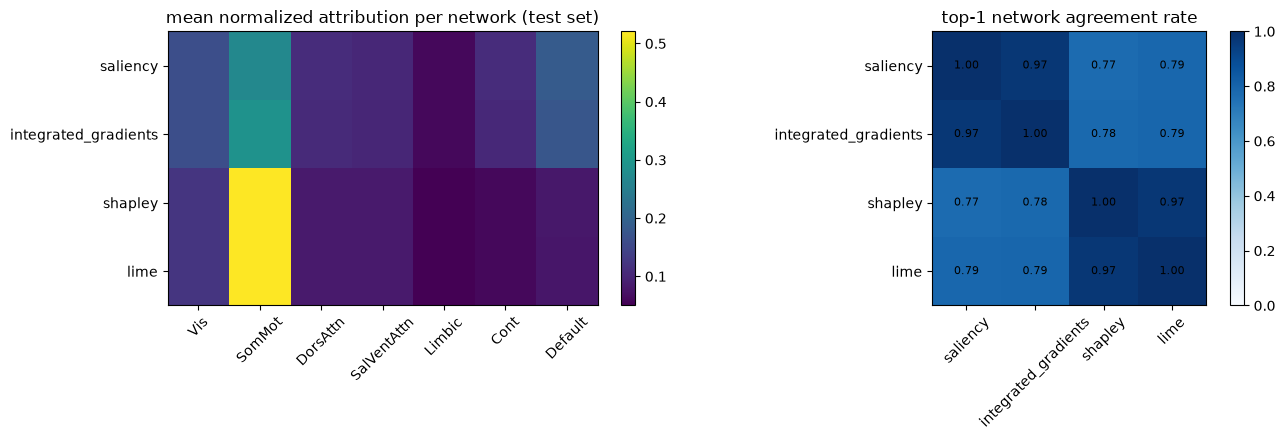

,saliency,integrated_gradients,shapley,lime
Vis,0.163,0.163,0.123,0.123
SomMot,0.270,0.291,0.521,0.520
DorsAttn,0.110,0.105,0.083,0.083
SalVentAttn,0.102,0.100,0.083,0.084
Limbic,0.060,0.061,0.050,0.051
Cont,0.109,0.104,0.059,0.060
Default,0.185,0.176,0.080,0.078


In [7]:
mean_attribution = pd.DataFrame(
    {method: [attribution_df[f"{method}__{net}"].mean() for net in NETWORK_NAMES] for method in METHODS},
    index=NETWORK_NAMES,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

im = axes[0].imshow(mean_attribution.T.values, cmap="viridis", aspect="auto")
axes[0].set_xticks(range(len(NETWORK_NAMES)))
axes[0].set_xticklabels(NETWORK_NAMES, rotation=45)
axes[0].set_yticks(range(len(METHODS)))
axes[0].set_yticklabels(METHODS)
axes[0].set_title("mean normalized attribution per network (test set)")
fig.colorbar(im, ax=axes[0], fraction=0.046)

im2 = axes[1].imshow(agreement.values.astype(float), cmap="Blues", vmin=0, vmax=1)
axes[1].set_xticks(range(len(METHODS)))
axes[1].set_xticklabels(METHODS, rotation=45)
axes[1].set_yticks(range(len(METHODS)))
axes[1].set_yticklabels(METHODS)
axes[1].set_title("top-1 network agreement rate")
for i in range(len(METHODS)):
    for j in range(len(METHODS)):
        axes[1].text(j, i, f"{agreement.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im2, ax=axes[1], fraction=0.046)

fig.tight_layout()
plt.show()

mean_attribution.round(3)


## 4. End-to-end example: decoded state → RSN → templated query

This is the piece that plugs into the RAG step: a decoded state plus its top-attributed RSN becomes a text query against the `01_pdf_ingestion` retrieval index.

In [8]:
example = per_window_df.iloc[0]
example_attr = attribution_df.iloc[0]

print(f"Decoded state:")
print(f"  subject={example['subject_id']} run={example['run']} target_volume={example['target_volume']}")
print(f"  predicted condition: {example['condition']} (confidence={example['confidence']:.2f})")
print(f"  true condition:      {example['true_condition']}")
print()
print("Top RSN by method:")
for method in METHODS:
    top_net = example_attr[f"top1__{method}"]
    score = example_attr[f"{method}__{top_net}"]
    print(f"  {method:22s} -> {top_net:12s} ({score:.2f})")

consensus_top_net = example_attr[[f"top1__{m}" for m in METHODS]].mode()[0]

query_text = (
    f"Decoded condition: {example['condition']} (confidence {example['confidence']:.0%}). "
    f"Primary contributing resting-state network: {consensus_top_net}. "
    f"MOTOR task, subject {example['subject_id']}, run {example['run']}."
)
print()
print("Templated query for RAG retrieval:")
print(" ", query_text)


Decoded state:
  subject=101915 run=LR target_volume=31
  predicted condition: right_hand (confidence=1.00)
  true condition:      right_hand

Top RSN by method:
  saliency               -> SomMot       (0.28)
  integrated_gradients   -> SomMot       (0.35)
  shapley                -> SomMot       (0.96)
  lime                   -> SomMot       (0.95)

Templated query for RAG retrieval:
  Decoded condition: right_hand (confidence 100%). Primary contributing resting-state network: SomMot. MOTOR task, subject 101915, run LR.


## Summary

- Re-run on the 20-subject dataset (14 train / 3 val / 3 test) against the retrained Experiment 4 checkpoint. Per-window predictions and per-window RSN attribution (4 methods x 7 networks) are saved to `results/motor_v1_per_window_predictions.csv` and `results/rsn_attribution_per_window.csv`.
- **The two-cluster pattern persists, but agreement improved with more data and a more confident model.** Saliency/IG agree with each other 97.0% of the time (0.94 rank correlation); Shapley/LIME agree 97.0% of the time (0.91). Across families, agreement rose from ~65% (5-subject run) to **~78%** top-1, and rank correlation from ~0.39 to **~0.43-0.47** — a better-trained, higher-confidence model produces attributions the two method families agree on more often, though the underlying disagreement (gradient methods still over-weighting the Default network, ~18% vs ~8% for perturbation methods) has not gone away.
- The single-window example above now decodes with 100% confidence (vs. 53% in the 5-subject run) and all four methods agree on SomMot as the top network — consistent with the much higher classification accuracy at 20-subject scale (test macro F1 0.925 vs 0.632 for Experiment 4; see docs/ml-design-report.md §9).
- Gradient-based (Saliency, IG) and perturbation-based (Shapley, LIME) remain two genuinely different mechanisms pooled to the same 7-network output for comparability — see [docs/interpretability-methods-notes.md](../docs/interpretability-methods-notes.md) for the full rationale, this gradient-vs-perturbation discrepancy as a named open question, and a survey of methods not implemented here (including Been Kim's concept-based interpretability line).
